# Face Detection project
La ProCam s.p.a ha intenzione di lanciare sul mercato una nuova fotocamera digitale compatta ed economica destinata a piccoli fotografi in erba. Si viene assunti come Data Scientist per realizzare il sistema di identificazione dei volti nelle immagini, questo permetterà poi ai tecnici della fotografia di ottimizzare le impostazioni per un selfie con una o più persone. Si tratta di un problema di computer vision, più precisamente di Face Detection.
Si dovrà fornire una pipeline scikit-learn che prende un'immagine in ingresso e ritorna una lista con le coordinate dei bounding box dove sono presenti dei volti, se nell'immagine non contiene volti la lista sarà ovviamente vuota.

#### Note progettuali
1) Non viene fornito un dataset, si può cercarne uno in rete o, nella peggiore delle ipotesi, costruirlo, per semplicità non considereremo implicazioni sulle licenze ad utilizzo commerciale, si tratta pur sempre di un progetto didattico;

2) Non si possono utilizzare modelli pre-addestrati, bisogna addestrarne uno utilizzando scikit-learn;

3) Si sta lavorando su un sistema con ridotte capacità di calcolo, quindi il modello dovrà richiedere poche risorse di calcolo;

4) Ovviamente non vengono fornite indicazioni sull'implementazione, fare un'approfondita ricerca bibliografica per trovare la soluzione migliore da adottare, il notebook che si consegnerà dovrà essere ben documentato, spiegando quali soluzioni si sono adottate e perché ed ogni risorsa esterna (paper, blog post, codice github...) utilizzata.

### Import librerie
Di seguito l'import di tutte le librerie che adotteremo nel flusso di lavoro.

In [1]:
import numpy as np
import joblib, pickle, cloudpickle
from joblib import Parallel, delayed
import os, zipfile, random, cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from skimage import color

### Descrizione del flusso di lavoro
In questa sezione descriviamo gli step principali per la costruzione di un tool di face detection, ispirato all'iconico articolo "Histograms of Oriented Gradients for Human Detection" di Dalal e Triggs (2005). In questo lavoro, gli autori utilizzano la tecnica HOG (Histograms of Oriented Gradients) per rappresentare visivamente le immagini e impiegano una Support Vector Machine (SVM) per la classificazione finale. Una volta addestrato il modello SVM tramite le HOG features, questo viene applicato a sotto-porzioni dell'immagine attraverso la tecnica delle Sliding Windows per il rilevamento.

Gli step principali del processo che seguiremo sono i seguenti:
- Preprocessing: caricamento delle immagini di volti e non volti, conversione in scala di grigi, ridimensionamento e applicazione di denoising per migliorare la qualità delle immagini.

- Creazione del dataset: assegnazione delle label appropriate (1 per i volti, 0 per le immagini di non volti).

- Estrazione delle HOG features: utilizzo della tecnica HOG per estrarre le caratteristiche distintive dalle immagini.

- Addestramento della SVM: suddivisione del dataset in training e test set, seguita dall'addestramento di un modello SVM per la classificazione.

- Valutazione del modello: test delle prestazioni del modello su un set di immagini di test.

- Predizione su nuove immagini: applicazione della tecnica delle Sliding Windows per effettuare predizioni su nuove immagini.

#### Link utili
- HOG features: https://lear.inrialpes.fr/people/triggs/pubs/Dalal-cvpr05.pdf
- HOG tecniques: https://www.cs.utoronto.ca/~fidler/slides/CSC420/lecture17.pdf
- Pyramid models: https://engineering.jhu.edu/vpatel36/wp-content/uploads/2018/08/DeepPyramid_btas2015.pdf

### Costruzione dell'images dataset
In questo primo step, creiamo un dataset contenente immagini di volti e non volti. Le immagini di volti provengono da un sottoinsieme di 3000 immagini tratte dal dataset Flick_Faces, disponibile gratuitamente sulla piattaforma Kaggle. Per quanto riguarda le immagini di non volti, sono state selezionate 1500 fotografie di paesaggi prese dal dataset Landscapes e 1400 fotografie di oggetti da quello di Object Detection sempre su Kaggle. Le immagini sono contenute nello zip Training_Set.zip, salvate in due rispettive folder Faces_training e No_faces_training. Pertanto, l'idea di base è di partire da uno zip contenente tutte le immagini necessarie alla costruzione della SVM finale. Nella sezione seguente, il processo di costruzione prevede l'estrazione dei file dallo zip Training_set.zip costituito dalle due sottofolder di volti e non volti (Faces_training e No_faces_training).

#### Link utili alla costruzione del Training_Set.zip
- Landscapes dataset: https://www.kaggle.com/datasets/arnaud58/landscape-pictures \\
- Flickr_Faces dataset: https://www.kaggle.com/datasets/arnaud58/flickrfaceshq-dataset-ffhq \\
- Objects Detection dataset: https://www.kaggle.com/datasets?search=object+detection


In [ ]:
# Path dello zip e della folder di estrazione (sostituire con rispettivi path dedicati)
zip_path = r'Projects\MatteoMarcoCosta - Progetto 6\Dataset\Training_set.zip'
estrai_in = r'Projects\MatteoMarcoCosta - Progetto 6\Dataset\Data'

# Creazione della folder estrain_in (sempre se questa non esista già)
os.makedirs(estrai_in, exist_ok=True)

# Apertura del file zip (modalità reading 'r')
with zipfile.ZipFile(zip_path, 'r') as zipf:
    for nome_file in zipf.namelist(): # Ciclo su tutti i file e folder contenute nello zip
        if nome_file.endswith('/'):
            continue
        percorso_destinazione = os.path.join(estrai_in, nome_file) # Path finale di estrazione
        if not os.path.exists(percorso_destinazione): # Se il file non esiste viene estratto ...
            print(f"Estraggo: {nome_file}")
            zipf.extract(nome_file, estrai_in)
        else: # ... altrimenti se esiste già non viene sovrascritto
            print(f"File già presente, salto: {nome_file}")

Estraggo: Faces_training/00000.png
Estraggo: Faces_training/00001.png
Estraggo: Faces_training/00002.png
Estraggo: Faces_training/00003.png
Estraggo: Faces_training/00004.png
Estraggo: Faces_training/00005.png
Estraggo: Faces_training/00006.png
Estraggo: Faces_training/00007.png
Estraggo: Faces_training/00008.png
Estraggo: Faces_training/00009.png
Estraggo: Faces_training/00010.png
Estraggo: Faces_training/00011.png
Estraggo: Faces_training/00012.png
Estraggo: Faces_training/00013.png
Estraggo: Faces_training/00014.png
Estraggo: Faces_training/00015.png
Estraggo: Faces_training/00016.png
Estraggo: Faces_training/00017.png
Estraggo: Faces_training/00018.png
Estraggo: Faces_training/00019.png
Estraggo: Faces_training/00020.png
Estraggo: Faces_training/00021.png
Estraggo: Faces_training/00022.png
Estraggo: Faces_training/00023.png
Estraggo: Faces_training/00024.png
Estraggo: Faces_training/00025.png
Estraggo: Faces_training/00026.png
Estraggo: Faces_training/00027.png
Estraggo: Faces_trai

A questo punto iniziamo a caricare le immagini estratte dallo zip. L'obiettivo e creare il dataset
di training della successiva SVM. Nella function seguente si esegue anche una prima fase di preprocessamento che comprende una prima conversione in scala di grigi e un ridimensionamento a 96x96 pixel. La scelta 96x96 è uno standard abbastanza comune, chiaramente si potrebbe sperimentare con dimensioni diverse; anche per i successivi step adotteremo questa dimensione.

In [ ]:
# Funzione di caricamento di immagini: specificare la folder contenente le immagini
def load_images_from_folder(folder, max_images=None):
    
    images = []                                         # Lista inizializzata a vuoto
    for filename in os.listdir(folder):                 # Ciclo sulla folder contenente le immagini
        img_path = os.path.join(folder, filename)       # Path dell'immagine
        img = cv2.imread(img_path)                      # Lettura dell'immagine tramite cv2
        if img is not None:                             # Se l'immagine viene letta correttamente ...
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Conversione in scala di grigi
            img = cv2.resize(img, (96, 96))             # Ridimensionamento a 96x96
            images.append(img)                          # Append alla lista images
        if max_images and len(images) >= max_images:    # In caso di limite di lettura raggiunto, stop del ciclo
            break
    return images

# Folder contenenti le immagini di volti e non volti ottenuti dall'estrazione dello zip
positive_images_path = r'Projects\MatteoMarcoCosta - Progetto 6\Dataset\Data\Faces_training'
negative_images_path = r'Projects\MatteoMarcoCosta - Progetto 6\Dataset\Data\No_faces_training'

# Caricamento delle immagini positive (facce) e negative (non facce). Le due folder Faces_training e
# No_faces_training contengono rispettivamente 3000 e 2900 immagini png
positive_images = load_images_from_folder(positive_images_path, max_images=3000)
negative_images = load_images_from_folder(negative_images_path, max_images=2900)

# Unione finale delle immagini
dataset = np.array(positive_images + negative_images)
print(f"Caricate {len(dataset)} immagini in totale")

Caricate 5900 immagini in totale


## Processamento delle immagini
Il processamento preliminare delle immagini serve a facilitare la successiva estrazione delle Hog Features e la modellizzazione tramite SVM. Nello specifico, la funzione che andiamo ora a costruire:

- converte le immagini in scala di grigi (come check ulteriore e per ridurre dimensionalità e complessità);
- le ridimensiona (in particolare, standardizza la dimensione per il training della SVM);
- applica un denoising finale per rimuovere il rumore e migliorare la qualità del dato.

La funzione sarà applicata alle due liste positive_images e negative_images prima create. La tecnica di denosing finale ha l'obiettivo di rimuovere eventuale rumore, ad esempio pixel random o disturbi spesso presenti quando si lavora con immagini digitali.

In [3]:
# process_image function: funzione per processare l'immagine
def process_image(image, resize=True, img_resize=(96, 96), denoise=True):

    # Verifica che l'immagine sia stata letta correttamente
    if image is None:
        print("Errore nel caricare l'immagine")
        return None
    if len(image.shape) == 3: # Conversione in scala di grigi come check ulteriore
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # Conversione in scala di grigi
    if resize: # Ridimensionamento come check ulteriore
        image = cv2.resize(image, img_resize)#Ridimensionamento
    if denoise: # Denoising
        image = cv2.fastNlMeansDenoising(image, None, 10, 7, 21)#Denoising finale
    return image

# Nella function process_image sono state lasciate di default a True il resize, il denoise e
# la resize-dimension a 96x96 pixel

# Processamento delle immagini
processed_positive_images = [process_image(img) for img in positive_images]
processed_negative_images = [process_image(img) for img in negative_images]

# Unione delle immagini processate
dataset = np.array(processed_positive_images + processed_negative_images)

# Verifica che le immagini siano state caricate e processate correttamente
print(f"Numero di immagini caricate e processate: {len(dataset)}")

Numero di immagini caricate e processate: 5900


Proviamo ora a effettuare un check sulle procedure finora addottate. Scegliamo a random un campione di n-immagini tra volti e non volti. Possiamo notare come le immagini di non volti siano variegate: paesaggi, oggetti, scatti casuali, animali e molte altre casistiche.

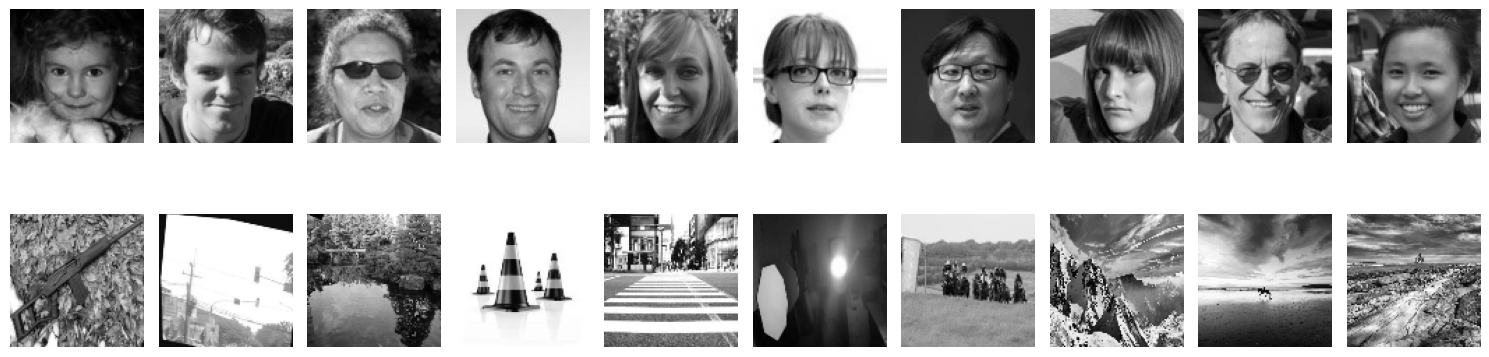

In [6]:
# Funzione random_images: selezione di n-immagini in modo random dalle liste di immagini
def random_images(num_images):
    random_positive = random.sample(positive_images, num_images)
    random_negative = random.sample(negative_images, num_images)

    # Visualizzazione finale
    fig, ax = plt.subplots(2, num_images, figsize=(15, 5)) # Plot su due righe

    for i in range(num_images):
        ax[0, i].imshow(random_positive[i], cmap='gray') # Campione random di volti
        ax[0, i].axis('off')

        ax[1, i].imshow(random_negative[i], cmap='gray') # Campione random di non volti
        ax[1, i].axis('off')

    plt.tight_layout()
    plt.show()

random_images(num_images = 10) # Estrazione di 10 immagini su ogni dataset

## HOG Features
Per l'applicazione del successivo modello di SVM, è necessario l'estrazione delle HOG Features da ogni immagine prima processata. Nello specifico, la HOG (Histogram of Oriented Gradients) è una tecnica di estrazione di caratteristiche usata principalmente per il riconoscimento di oggetti, come nel nostro contesto di face detection. La tecnica consiste nell'analisi dell'orientamento e dell'intensità dei gradienti (cambiamenti di intensità) in piccole sotto-aree dell'immagine considerata. Le caratteristiche HOG cercano di catturare forme e i bordi degli oggetti, in modo da fornire una versione semplificata ma significativa dell'intera immagine.

### Tecnica dei gradienti
Come prima accennato, il metodo HOG (Histogram of Oriented Gradients) è una tecnica usata per l'estrazione di feature da immagini, particolarmente efficace per il riconoscimento di oggetti come i volti. Per ulteriori approfondimenti visionare le seguenti risorse online:

- builtin.com: https://builtin.com/articles/histogram-of-oriented-gradients
- Wikipedia: https://en.wikipedia.org/wiki/Histogram_of_oriented_gradients

#### Calcolo dei gradienti
Per ogni pixel dell'immagine $I$ (intesa come matrice di numeri reali), calcoliamo il gradiente orizzontale $G_x$ e verticale $G_y$. In ottica RGB, con abuso di notazione, in questi contesti con vettore gradiente si intende che le rispettive componenti (derivate parziali) siano derivate in senso discreto e non in senso analitico. Nel caso di un'immagine bidimensionale, come nel nostro caso, la costruzione del gradiente avviene tramite tecnica di derivazione discreta o, in casi più sofisticati, tramite convoluzioni discrete (vedi ad esempio tecniche Sobel). Un esempio classico di approccio discreto, per il calcolo delle derivate nel punto $(x,y)$, è il seguente:

<br>

$$G_x(x,y) = \frac{\partial I}{\partial x} \sim I(x+1, y) - I(x, y),$$
$$G_y(x,y) = \frac{\partial I}{\partial y} \sim I(x, y+1) - I(x, y),$$

<br>

dove con $I(x,y)$ intendiamo il pixel di coordinate $(x,y)$ all'interno della matrice immagine $I$. Ad esempio, consideriamo una sottomatrice di $I$ (ovvero una sotto-porzione dell'immagine) e supponiamo, applicando le definizioni precedenti, di ottenere una matrice

<br>

$$
G_x =
\begin{bmatrix}
30 & 30 & 30\\
30 & 30 & 30\\
30 & 30 & 30
\end{bmatrix}
$$

<br>

i cui elementi sono tutti costanti. Questo significa che a livello orizzontale, in tale sottoporzione dell'immagine, avviene una variazione costante di intensità. In generale, si potrebbe osservare che più $G_x > 0$ più l'intensità varia da scuro a chiaro mentre più $G_x < 0$ più l'intensità varia da chiaro a scuro. Nel nostro esempio di prima, gli elementi rimangono costanti il che consente di dedurre una variazione uniforme di intensità. Un discorso analogo vale anche per le derivate verticali $G_y$.

#### Tecniche di padding
In generale, vengono spesso applicate tecniche di gestione dei bordi delle immagini, note come tecniche di padding:

- zero padding: estensione dell'immagine con una cornice di pixel valorizzati a 0;
- replicated padding: si replica nel bordo il valore vicino;
- reflected padding: valori sul bordo specchiati.

Un'altra tecnica di derivazione discreta, abbastanza diffusa in analisi numerica, è la derivazione centrale:

<br>

$$G_x(x,y) = \frac{\partial I}{\partial x} \sim \frac{I(x+1, y) - I(x-1, y)}{2}.$$

<br>

Di seguito un elenco di ulteriore risorse interessanti come approfondimento:

- Discrete derivations: https://en.wikipedia.org/wiki/Discrete_calculus 
- Hog Gradients: https://towardsdatascience.com/histogram-of-oriented-gradients-hog-in-computer-vision-a2ec66f6e671/

#### Magnitudine e orientazione
Dal calcolo dei gradienti si ottiene poi:

- La **magnitudine del gradiente**:

  $$M = \sqrt{G_x^2 + G_y^2}.$$

- L'**orientazione del gradiente** spesso espressa in radianti:

  $$\theta = \arctan\left(\frac{G_y}{G_x}\right).$$


#### Istogrammi locali
L'immagine viene divisa in **celle** (tipicamente 8×8 pixel). Per ogni cella si costruisce un istogramma delle orientazioni, divise in **bin**. Ogni pixel contribuisce all'istogramma proporzionalmente alla sua magnitudine.

#### Normalizzazione dei blocchi
Per rendere le feature robuste a variazioni di contrasto o luminosità, le celle vengono raggruppate in **blocchi** (es. 2×2 celle), e il vettore concatenato viene normalizzato, ad esempio tramite **L2-norm**:

<br>

$$v \rightarrow \frac{v}{\sqrt{\|v\|_2^2 + \epsilon^2}},$$

<br>

dove $\epsilon$ è un valore preso a piacere per stabilizzare le componenti a denominatore. Il risultato finale è un vettore di feature HOG che rappresenta i pattern di orientazione locali dell'immagine, ed è usato come input per classificatori come la SVM.

Di seguito si costruisce la extract_HOG_features function che consente per ogni immagine l'estrazione di tali caratteristiche.

In [7]:
def extract_HOG_features(image,
                         resize=(96, 96),        # Ridimensionamento dell'immagine
                         pixels_per_cell=(8, 8), # Dimensione delle sotto-aree
                         cells_per_block=(2, 2), # Dimensione di normalizzazione locale
                         visualize=False):       # Se True ritorna anche l'immagine hog
    image = cv2.resize(image, resize)            # Ulteriore check sul ridimensionamento dell'immagine

    # Applicazione della hog function
    if visualize: # Se True return delle hog features e della hog image
        features, hog_image = hog(image, orientations=9, pixels_per_cell=pixels_per_cell,
                                  cells_per_block=cells_per_block, visualize=True, channel_axis=None)
        return features
    else: # Se False return delle sole hog features
        features = hog(image, orientations=9, pixels_per_cell=pixels_per_cell,
                        cells_per_block=cells_per_block, visualize=False, channel_axis=None)
        return features

# Estrazione delle caratteristiche HOG per ciascuna immagine sui dataset prima
# processati processed_positive_images e processed_negative_images
positive_features = [extract_HOG_features(img) for img in processed_positive_images]
negative_features = [extract_HOG_features(img) for img in processed_negative_images]

# Creazione delle labels per la classificazione della SVM successiva
positive_labels = [1] * len(positive_features) # 1 per le facce
negative_labels = [0] * len(negative_features) # 0 per le non facce

In [8]:
# Associazione delle caratteristiche e delle labels (per successiva fase di training della SVM)
X = np.array(positive_features + negative_features)
y = np.array(positive_labels + negative_labels)

Applicata la tecnica HOG, di seguito proviamo a effettuare qualche esempio di estrazione dei gradienti. Andiamo a scegliere in modo randomico un'immagine tra i volti possibili.

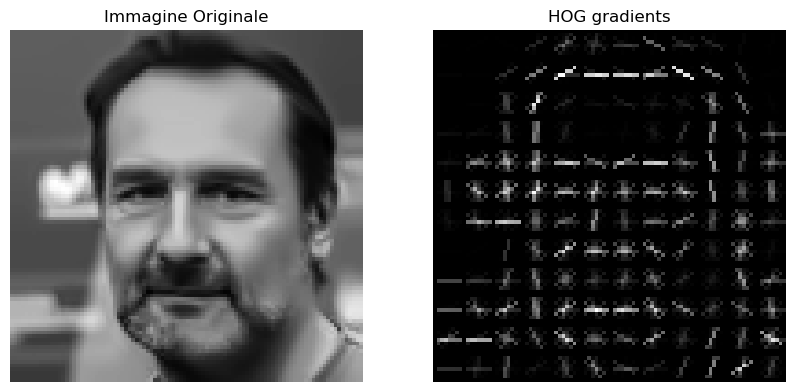

In [10]:
# Random selection di un'immagine dal dataset delle facce
random_idx = random.randint(0, len(processed_positive_images) - 1)
random_face = processed_positive_images[random_idx]

# Estrazione delle HOG features e dell'immagine dei gradienti
hog_features, hog_image = hog(random_face, 
                              orientations=9, 
                              pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), 
                              visualize=True, 
                              channel_axis=None)

# Plot dell'immagine originale e della hog image
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(random_face, cmap='gray')
ax[0].set_title("Immagine Originale")
ax[0].axis("off")

ax[1].imshow(hog_image, cmap='gray')
ax[1].set_title("HOG gradients")
ax[1].axis("off")

plt.show()

A destra possiamo osservare come la tecnica dei gradienti riesca a catturare efficacemente i pattern salienti del volto originale mostrato a sinistra, evidenziando i contorni e le strutture più rilevanti per l'analisi visiva. Per il modello SVM, le immagini dei volti tenderanno ad avere pattern simili.

## Addestramento della SVM
In questa sezione procediamo con l'addestramento della SVM (Support Vector Machine), il noto algoritmo di classificazione supervisionato che mira a separare le classi attraverso la determinazione di un iperpiano separatore ottimale. L'addestramento avverrà utilizzando le feature estratte precedentmente tramite tecnica HOG, che sintetizzano le informazioni principali dei volti.

In [11]:
# Splitting del dataset HOG (X ed y) in training set e test set. Per lo splitting 
# scegliamo la proporzione 30% e 70% tra test set e training set rispettivamente.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Per la costruzione della SVM applichiamo una tecnica di GridSearch con l'obiettivo di trovare dei parametri ottimali. In base al numero scelto di componenti del dizionario param_grid, il tempo di addestramento potrebbe richiedere qualche minuto. Possiamo notare che abbiamo 2 x 1 x 2 = 4 combinazioni di parametri a loro volta moltiplicati per cv = 3 (cross-validation su 3 fold), quindi un totale di 12 test. Chiaramente, si potrebbero aumentare le casisistiche modificando il dizionario param_grid. Viste le poche risorse di calcolo a disposizione, iniziamo a partire con queste 4 combinazioni prima esposte.

In [12]:
# Parametri da cercare con GridSearch
param_grid = {
    'C': [1, 10],                # Testiamo consdierando due valori per C
    'gamma': ['scale'],          # Consideriamo solo una scelta per gamma
    'kernel': ['linear', 'rbf'], # Proviamo a testare sia un kernel lineare che uno rbf
}

# Ottimizzazione con GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, scoring='accuracy', verbose=2)

# Fitting
grid_search.fit(X_train, y_train)

# Ottimizzazione completata: migliori parametri trovati
print("Migliori parametri trovati:", grid_search.best_params_)

# Eseguiamo la previsione con i migliori parametri
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Performance del modello sui dati di test
from sklearn.metrics import accuracy_score
print("Accuratezza del modello ottimizzato:", accuracy_score(y_test, y_pred))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Migliori parametri trovati: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Accuratezza del modello ottimizzato: 0.9983050847457627


Dall'ultimo output possiamo dunque determinare i parametri ottimali che consentiranno di definire la SVM ottimale. Qui di seguito procediamo con la definizione della SVM.

In [ ]:
# Definizione della svm con i parametri ottimali prima determinati (aggiunta anche del
# parametro class_weight='balanced' e del probability=True per usare la predict_proba successivamente)
svm = SVC(C=1, gamma='scale', kernel='linear', class_weight='balanced', probability=True)

# Fitting sul training set
svm.fit(X_train, y_train)

# Salvataggio del modello prima ottenuto (inserire un opportuno path di salvataggio)
joblib.dump(svm, r'Projects\MatteoMarcoCosta - Progetto 6\Model\svm_face_detector.pkl')

['C:\\Users\\MatteoMarcoCosta\\Desktop\\Anaconda\\Profession AI\\Projects\\MatteoMarcoCosta - Progetto 6\\Model\\svm_face_detector.pkl']

In [14]:
# Predizione sui dati di test
y_pred = svm.predict(X_test)

# Accuracy del modello
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuratezza del modello SVM: {accuracy:.2f}")

Accuratezza del modello SVM: 1.00


## Costruzione di una pipeline
Per ottimizzare l'applicazione del modello SVM, in questa sezione costruiamo una pipeline che automatizzi tutte le fasi di preprocessing necessarie. Questa pipeline prende in input un'immagine e restituisce direttamente le predizioni del classificatore assieme all'aggiunta di box che segnalano il contenimento del possibile volto. L'obiettivo è:

- processare l'immagine (scala di grigi, ridimensionamento, denoising);
- estrarre le feature HOG;
- applicare il modello SVM precedentemente addestrato.

Infine, il modello viene applicato su tutta l'immagine tramite la tecnica dello Sliding Window, che permette di scansionare l'immagine a blocchi per individuare le regioni contenenti un volto.

In [ ]:
# Check se è il modello è stato fittato correttamente
svm_loaded = joblib.load(r"Projects\MatteoMarcoCosta - Progetto 6\Model\svm_face_detector.pkl")

if hasattr(svm_loaded, "support_"):
    print("modello fitted")
else:
    print("ERROR: modello non fitted")

modello fitted


#### Alcune risorse interessanti:
- Esempi di pipeline per Face Detection: https://jakevdp.github.io/PythonDataScienceHandbook/05.14-image-features.html
- Pipeline in ottica Scikit-Learn: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
- Sliding Windows tecniques: https://pyimagesearch.com/2015/03/23/sliding-windows-for-object-detection-with-python-and-opencv/
- Sliding Windows methods: https://medium.com/@abhishekjainindore24/history-of-sliding-window-and-image-pyramids-in-object-detection-f52666ed88ab

In [ ]:
# COSTRUZIONE DELLA PIPELINE 

# 1) Caricamento del modello SVM
svm_model = joblib.load(r'Projects\MatteoMarcoCosta - Progetto 6\Model\svm_face_detector.pkl')

# 2) Image Pyramid Extractor ---> tecnica per generare versioni progressivamente più piccole (cioè scalate)
# della stessa immagine. In questo modo analizziamo le immagini a diverse scale
class ImagePyramidExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, scale=1.2, min_size=(96, 96)):
        self.scale = scale
        self.min_size = min_size#Stop finale della riduzione

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        pyramids = []#Lista di immagini
        for image in X:
            pyramid = []
            current = image.copy()

            # Fintanto che l’immagine è più grande o uguale alla dimensione minima ...
            while current.shape[0] >= self.min_size[1] and current.shape[1] >= self.min_size[0]:
                pyramid.append(current.copy()) # ... aggiungo l'immagine corrente alla piramide

                # Nuove dimensioni dell'immagine successiva
                new_w = int(current.shape[1] / self.scale)
                new_h = int(current.shape[0] / self.scale)
                current = cv2.resize(current, (new_w, new_h)) # Immagine riscalata che rientrerà nel while fino a min_size
            pyramids.append(pyramid)
        return pyramids

# 3) Sliding Window Extractor ---> applicazione di una finestra mobile (Sliding Windows) su ogni
# livello della piramide di immagini. La finestra ha una dimensione fissa ((96, 96)), e viene fatta
# scorrere attraverso l'immagine con un passo di 5 pixel (configurabile tramite step_size).
# In questo modo, vengono estratti dei pezzi di immagine (le cosidette "windows") che potrebbero contenere
# oggetti di interesse (nel nostro caso, volti)
class SlidingWindowExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, window_size=(96, 96), step_size=5):
        self.window_size = window_size
        self.step_size = step_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        all_windows = []
        for pyramid in X:
            windows = []
            for scale_idx, image in enumerate(pyramid):
                h, w = image.shape[:2]
                for y in range(0, h - self.window_size[1] + 1, self.step_size):
                    for x in range(0, w - self.window_size[0] + 1, self.step_size):
                        window = image[y:y + self.window_size[1], x:x + self.window_size[0]]
                        if window.shape[:2] == self.window_size:
                            windows.append({
                                "scale": scale_idx,
                                "x": x,
                                "y": y,
                                "image": window
                            })
            all_windows.append(windows)
        return all_windows

# 4) HOG Extractor ---> su ogni finestra estratta dal passo precedente vengono calcolate le HOG features
class HOGExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        hog_windows = []
        for windows in X:
            feats = []
            for w in windows:
                gray = color.rgb2gray(w['image'])
                hog_feat = hog(gray,
                               orientations=self.orientations,
                               pixels_per_cell=self.pixels_per_cell,
                               cells_per_block=self.cells_per_block,
                               visualize=False)
                feats.append({
                    "scale": w["scale"],
                    "x": w["x"],
                    "y": w["y"],
                    "hog": hog_feat
                })
            hog_windows.append(feats)
        return hog_windows

# 5) WindowClassifier ---> questa componente è il cuore del rilevamento: usa il modello SVM 
# precedentemente allenato per classificare le finestre estratte e decidere se contengono un 
# volto o meno. Per ogni finestra, il modello predice se contiene un volto (predizione "1") 
# oppure no (predizione "0"). Se la finestra viene classificata come contenente un volto, 
# vengono calcolate le sue coordinate scalandole in base alla dimensione originale dell'immagine
class WindowClassifier(BaseEstimator, TransformerMixin):
    def __init__(self, clf, pyramid_scale=1.2, window_size=(96, 96)):
        self.clf = clf#Nel nostro caso, la SVM addestrata
        self.pyramid_scale = pyramid_scale
        self.window_size = window_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        results = [] # Lista con i rilevamenti finali
        for windows in X:
            detections = []
            for w in windows:
                pred = self.clf.predict([w["hog"]])[0] # Predizione (tramite la SVM)
                if pred == 1:
                    scale_factor = self.pyramid_scale ** w["scale"]
                    x = int(w["x"] * scale_factor)
                    y = int(w["y"] * scale_factor)
                    w_box = int(self.window_size[0] * scale_factor)
                    h_box = int(self.window_size[1] * scale_factor)
                    detections.append((x, y, x + w_box, y + h_box))
            results.append(detections)
        return results

# 6) NMS manuale ---> applicazione dell'algoritmo di Non Maximum Suppression per selezionare solo i
# rilevamenti non ridondanti, restituendo un insieme finale di coordinate (bounding boxes).
# L'idea è di andare a rimuovere eventuali sovrapposizioni di riquadri di rilevamento nelle operazioni di
# rilevamento degli oggetti, in particolare nelle situazioni in cui vengono generati più riquadri per
# lo stesso oggetto (nel nostro caso volti)
class NMS(BaseEstimator, TransformerMixin):
    def __init__(self, overlapThresh=0.1):#overlapThresh: soglia di sovrapposizione tra i riquadri
        self.overlapThresh = overlapThresh

    def fit(self, X, y=None):#X indica una lista di rilevamenti (boxes)
        return self

    def transform(self, X):

        def non_max_suppression_fast(boxes, overlapThresh):

            # Se sono stati rilevati riquadri nell'immagine o frame, la funzione ritorna una lista vuota
            if len(boxes) == 0:
                return []
            boxes = np.array(boxes)     # Conversione in un array NumPy per facilitare le operazioni
            if boxes.dtype.kind == "i": # Conversione in floating, anche qui per agevolare la floating point
                boxes = boxes.astype("float")

            # Lista per memorizzare gli indici dei riquadri selezionati durante il processo di NMS
            pick = []

            # Coordinate del riaquadro (4 vertici)
            x1 = boxes[:,0]
            y1 = boxes[:,1]
            x2 = boxes[:,2]
            y2 = boxes[:,3]

            # Area del riquadro (aggiunta di un +1)
            area = (x2 - x1 + 1) * (y2 - y1 + 1)

            # Viene creato un array idxs che contiene gli indici dei riquadri ordinati in base alla
            # coordinata y2. Ordinare i riquadri in base alla loro posizione verticale è un passo comune
            # nell'algoritmo di NMS, poiché i riquadri che si trovano più in basso (con un valore maggiore
            # di y2) vengono considerati prima.
            idxs = np.argsort(y2)

            # Selezione del riquadro con il punteggio più alto e rimozione deii riquadri che si
            # sovrappongono in modo significativo
            while len(idxs) > 0:
                last = idxs[-1]
                pick.append(last)

                # xx1, yy1 sono le coordinate del punto superiore sinistro dell'intersezione tra il
                # riquadro last e tutti gli altri riquadri (tranne se stesso, quindi idxs[:-1]). In modo
                # analogo xx2 e yy2 sono le coordinate del punto inferiore destro dell'intersezione
                xx1 = np.maximum(x1[last], x1[idxs[:-1]])
                yy1 = np.maximum(y1[last], y1[idxs[:-1]])
                xx2 = np.minimum(x2[last], x2[idxs[:-1]])
                yy2 = np.minimum(y2[last], y2[idxs[:-1]])

                #Larghezza (w) e l'altezza (h) dell'area di intersezione
                w = np.maximum(0, xx2 - xx1 + 1)
                h = np.maximum(0, yy2 - yy1 + 1)

                # Overlap: viene calcolato come l'area dell'intersezione (w * h) divisa per l'area di
                # ciascun riquadro di confronto (area[idxs[:-1]]). Questo dice quanto i riquadri si
                # sovrappongono in relazione alla loro area. Se l'overlap è elevato, significa che i due
                # riquadri sono molto simili e uno può essere eliminato (np.delete)
                overlap = (w * h) / area[idxs[:-1]]
                idxs = np.delete(idxs, np.concatenate(([len(idxs) - 1],
                                np.where(overlap > overlapThresh)[0])))

            return boxes[pick].astype("int") # Lista finale dei riquadri selezionati (liste di 4 vertici)

        final_results = []   # Lista dei box finali
        for detections in X: # Ciclando sui box rilevati ...
            boxes = np.array(detections)
            if boxes.size == 0: # Se non ci sono box rilevati, riempimento a vuoto nella lista
                final_results.append([])
            else: # Altrimenti applichiamo la NMS e aggiorniamo la lista con le coordinate
                picks = non_max_suppression_fast(boxes, self.overlapThresh)
                final_results.append(picks)
        return final_results

# 7) Pipeline completa: inserimento delle varie classi
pipeline = Pipeline([
    ('pyramid', ImagePyramidExtractor(scale=1.2, min_size=(96, 96))),
    ('sliding', SlidingWindowExtractor(window_size=(96, 96), step_size=5)),
    ('hog', HOGExtractor()),
    ('clf', WindowClassifier(clf=svm_model, pyramid_scale=1.2, window_size=(96, 96))),
    ('nms', NMS(overlapThresh=0.1))
])

# 8) Salvataggio della pipeline (uso della cloudpickle più robusta per salvare pipeline customizzate)
with open(r'Projects\MatteoMarcoCosta - Progetto 6\Pipeline\pipeline.pkl', 'wb') as f:
    cloudpickle.dump(pipeline, f)

## Test del modello su nuovi dati
In questa sezione proviamo ad applicare il modello SVM e la pipeline su nuove immagini. Come anticipato, l'applicazione della SVM prevede l'uso della tecnica delle Sliding Windows.

In [ ]:
# Caricamento della pipeline
with open(r'Projects\MatteoMarcoCosta - Progetto 6\Pipeline\pipeline.pkl', 'rb') as f:
    pipeline_to_use = cloudpickle.load(f)

def tester(image_list, pipeline, max_dimension):

    for image_path in image_list:

        # Caricamento dell'immagine
        test_image = cv2.imread(image_path)
        test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

        # Ridimensionamento se l'immagine è troppo grande
        height, width = test_image.shape[:2]
        if max(height, width) > max_dimension:
            scale = max_dimension / max(height, width)
            new_size = (int(width * scale), int(height * scale))
            test_image = cv2.resize(test_image, new_size)

        # Applicazione della pipeline (tutti i metodi transform nell'ordine della pipeline)
        detections = pipeline.transform([test_image])[0]

        # Disegno dei bounding box sull'immagine originale
        output_image = test_image.copy()
        for (x1, y1, x2, y2) in detections:
            rgb_random_color = tuple(np.random.randint(0, 256, size=3).tolist()) # Colore random
            cv2.rectangle(output_image, (x1, y1), (x2, y2), rgb_random_color, 1) # Es. (0, 0, 255) è il blu

        # Visualizzazione dell'immagine finale con la face detection
        plt.figure(figsize=(8, 6))
        plt.imshow(output_image)
        plt.axis('off')
        plt.title('Face Detection')
        plt.show()

### Test su volti singoli

c:\Users\MatteoMarcoCosta\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


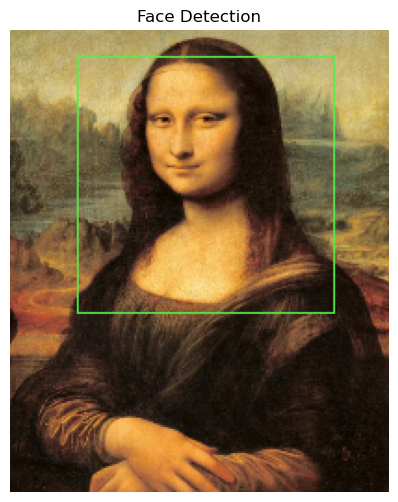

c:\Users\MatteoMarcoCosta\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


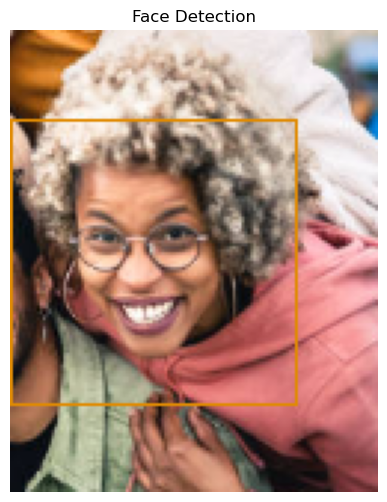

c:\Users\MatteoMarcoCosta\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


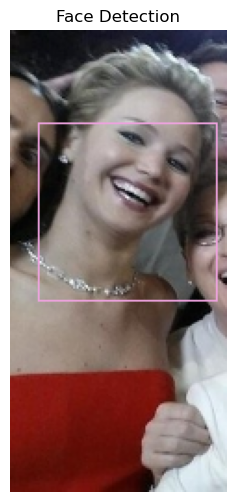

c:\Users\MatteoMarcoCosta\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


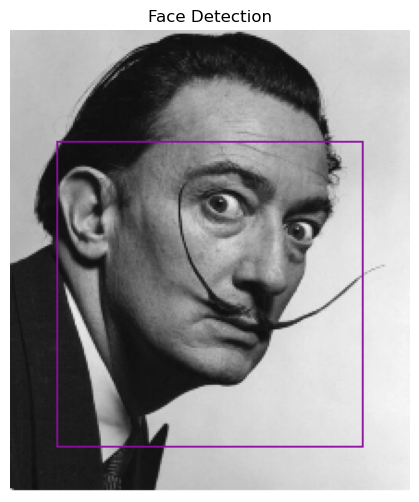

c:\Users\MatteoMarcoCosta\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


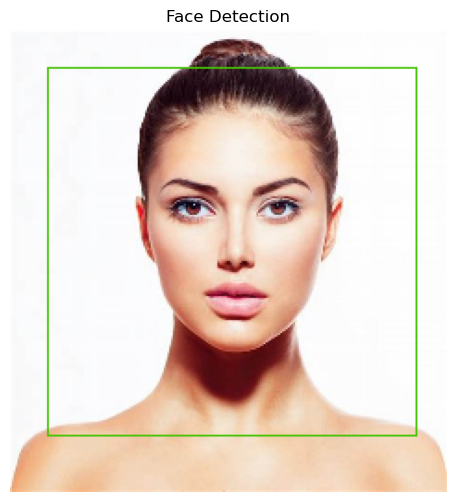

c:\Users\MatteoMarcoCosta\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


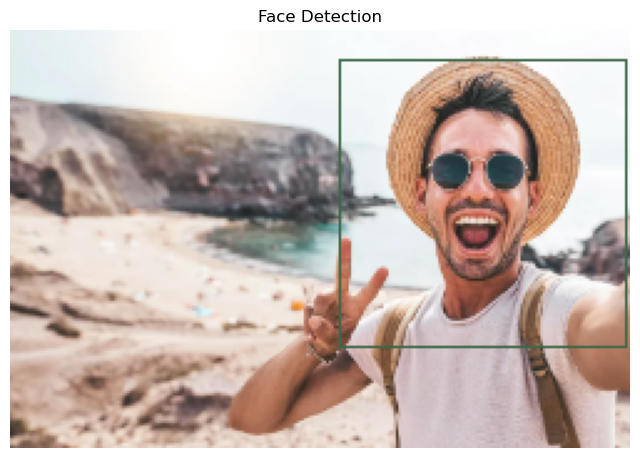

In [ ]:
# Test su una lista di immagini
path_images = r'Projects\MatteoMarcoCosta - Progetto 6\Dataset\Test_images'

images = [f'{path_images}/J.PNG',
          f'{path_images}/B.PNG',
          f'{path_images}/F.png',
          f'{path_images}/S.PNG',
          f'{path_images}/G.png',
          f'{path_images}/I.PNG',]

# N.B. Attenzione al case sensitive dei nomi e delle estensioni delle immagini
tester(images, pipeline_to_use, 250) # Alcuni parametri ottimali in base alle dimensioni delle immagini prese: 220, 250

### Test su immagini di gruppo
In questa sezione proviamo alcuni test su immagini di gruppo che hanno diverse dimensioni.

c:\Users\MatteoMarcoCosta\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


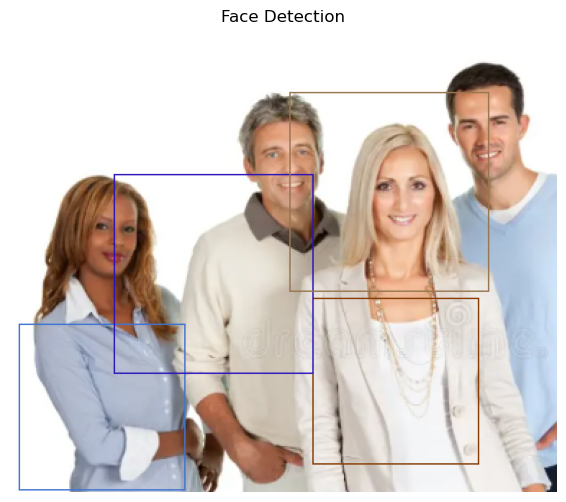

In [32]:
images_group = [r'Projects\MatteoMarcoCosta - Progetto 6\Dataset\Test_images\group1.png']

# N.B. Attenzione al case sensitive dei nomi e delle estensioni delle immagini
tester(images_group, pipeline_to_use, 380)

c:\Users\MatteoMarcoCosta\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


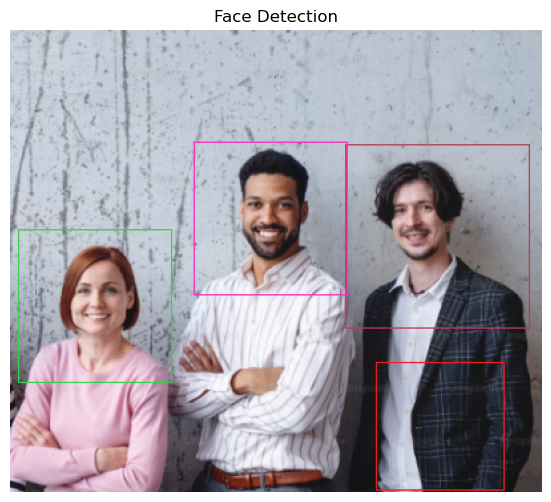

In [ ]:
images_group = [r'Projects\MatteoMarcoCosta - Progetto 6\Dataset\Test_images\group2.png']

# N.B. Attenzione al case sensitive dei nomi e delle estensioni delle immagini
tester(images_group, pipeline_to_use, 400)

### Conclusioni e sviluppi futuri
Nel presente progetto è stato sviluppato un sistema di Face Detection. La pipeline finale include fasi di estrazione della piramide di immagini, finestre scorrevoli (tecnica delle Sliding Windows), estrazione di features HOG, classificazione con SVM, e infine l'applicazione di Non-Maximum Suppression (NMS) per eliminare rilevazioni ridondanti. L'obiettivo principale era quello di costruire un sistema veloce per il rilevamento dei volti in immagini, avendo a disposizione poche risorse.
Come possibile sviluppo futuro, sarebbe interessante esplorare l'integrazione di tecniche di Deep Learning, come le reti neurali convoluzionali (CNN), per migliorare ulteriormente la precisione del rilevamento facciale. 
Inoltre, l'uso di tecniche di data augmentation e il miglioramento del dataset potrebbero contribuire ad aumentare la robustezza del modello, come ad esempio nella gestione di casistiche più complesse.